# Figure 1 and S3: Paired Day-Night Slopegraph

This notebook isolates the minimal code needed to reproduce the paired day-night slopegraph from A_batch_respirometry_final.ipynb.

## Load data from batch_summary.csv which is created by Notebook A. Execute style code for figure

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Locate the processed batch summary from common notebook working directories
candidate_paths = [
    Path.cwd() / "../data/processed/batch_summary.csv",
    Path.cwd() / "data/processed/batch_summary.csv",
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/batch_summary.csv")

agg_df = pd.read_csv(data_path)
analysis_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

pair_trials = [
    ('trial4', 'trial4.5'),
    ('trial5', 'trial5.5'),
    ('trial6', 'trial6.5'),
    ('trial7', 'trial7.5'),
]

paired_rows = []
for t_a, t_b in pair_trials:
    pair_df = analysis_df[analysis_df['trial'].isin([t_a, t_b])]
    if pair_df.empty:
        continue

    for (brick, channel), grp in pair_df.groupby(['brick', 'channel']):
        if len(grp) != 2:
            continue

        envs = set(grp['environment'])
        if envs != {'day', 'night'}:
            continue

        night_row = grp[grp['environment'] == 'night'].iloc[0]
        day_row = grp[grp['environment'] == 'day'].iloc[0]
        paired_rows.append({
            'pair': f'{t_a}_vs_{t_b}',
            'brick': brick,
            'channel': channel,
            'night': float(night_row['RMR']),
            'day': float(day_row['RMR']),
            'diff_night_minus_day': float(night_row['RMR'] - day_row['RMR']),
        })

paired_df = pd.DataFrame(paired_rows)
print(f'Loaded {len(agg_df)} total rows from {data_path}')
print(f'Paired day-night comparisons: {len(paired_df)}')
display(paired_df)

Loaded 71 total rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Paired day-night comparisons: 17


,pair,brick,channel,night,day,diff_night_minus_day
0,trial5_vs_trial5.5,box3,Ch2,2.285837,2.245259,0.040578
1,trial5_vs_trial5.5,box3,Ch3,0.920854,0.427888,0.492965
2,trial5_vs_trial5.5,box3,Ch4,0.473624,0.706451,-0.232827
3,trial5_vs_trial5.5,newbox,Ch2,1.871534,0.756193,1.115341
4,trial5_vs_trial5.5,newbox,Ch3,1.876437,1.199553,0.676884
5,trial5_vs_trial5.5,newbox,Ch4,2.681803,2.995435,-0.313632
6,trial6_vs_trial6.5,box3,Ch2,1.954137,0.949858,1.004280
7,trial6_vs_trial6.5,box3,Ch4,2.182509,0.679472,1.503037
8,trial6_vs_trial6.5,newbox,Ch2,3.222056,1.841349,1.380707
9,trial6_vs_trial6.5,newbox,Ch3,1.424907,0.920279,0.504627


In [2]:
# Load shared Figure style + palette
from pathlib import Path
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


## Plot the figure

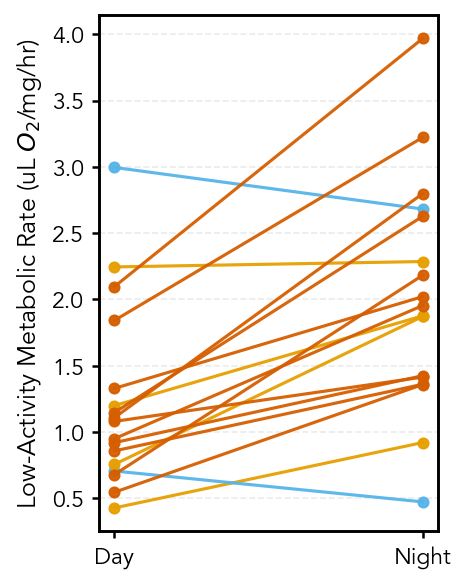

In [3]:
# Slopegraph: Day (left) vs Night (right) for paired comparisons
from matplotlib.lines import Line2D

if paired_df.empty:
    print('No paired data available to plot.')
else:
    plot_df = paired_df.copy()
    plot_df['label'] = plot_df['brick'] + ' | ' + plot_df['channel'] + ' | ' + plot_df['pair']
    plot_df = plot_df.sort_values(['pair', 'brick', 'channel'])

    # Trial start condition used for shade meaning.
    started_in_day = {'trial4_vs_trial4.5', 'trial5_vs_trial5.5'}

    fig, ax = plt.subplots(figsize=(3.2, max(4, 0.1 * len(plot_df))))
    x_day, x_night = 0, 1

    for _, row in plot_df.iterrows():
        y_day = row['day']
        y_night = row['night']
        pair = row['pair']

        # Direction encoded by hue family; start condition encoded by shade.
        if y_night > y_day:
            color = LIGHT_ORANGE if pair in started_in_day else DARK_ORANGE
        else:
            color = LIGHT_BLUE if pair in started_in_day else DARK_BLUE

        ax.plot(
            [x_day, x_night],
            [y_day, y_night],
            marker='o',
            markersize=4.8,
            color=color,
            linewidth=1.5,
            alpha=0.95,
        )

    ax.set_xticks([x_day, x_night])
    ax.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    plt.tight_layout()
    plt.show()

In [4]:
# Save the primary Figure 1 as a PDF.
from pathlib import Path

figures_dir = Path.cwd() / "../figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    pdf_path = (figures_dir / 'Figure1_SlopeGraph.pdf').resolve()

    fig.savefig(pdf_path, bbox_inches='tight')

    print(f"Saved PDF: {pdf_path}")
else:
    print("No figure object found. Run the plotting cell first.")

Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_SlopeGraph.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_SlopeGraph.pdf


## Statistical tests associated with the figure

In [5]:
# Statistical tests for paired day-night comparisons
from scipy import stats
import numpy as np

if paired_df.empty:
    print('No paired data available for statistical testing.')
else:
    stats_df = paired_df.copy()

    print('Paired statistical tests (night vs day)')
    print('=' * 60)

    # Overall paired tests across all matched pairs
    t_stat, p_t = stats.ttest_rel(stats_df['night'], stats_df['day'])

    try:
        w_stat, p_w = stats.wilcoxon(stats_df['night'], stats_df['day'], alternative='two-sided')
    except ValueError:
        w_stat, p_w = np.nan, np.nan

    print('\nOverall:')
    print(f"  n pairs = {len(stats_df)}")
    print(f"  mean night = {stats_df['night'].mean():.3f}")
    print(f"  mean day = {stats_df['day'].mean():.3f}")
    print(f"  mean diff (night - day) = {stats_df['diff_night_minus_day'].mean():.3f}")
    print(f"  Paired t-test: t = {t_stat:.3f}, p = {p_t:.4f}")
    print(f"  Wilcoxon signed-rank: W = {w_stat:.3f}, p = {p_w:.4f}")

    # Caption-ready sentence that adapts to full vs subsetted analyses
    sig_text = 'significantly' if (not np.isnan(p_w) and p_w < 0.05) else 'not significantly'
    n_unique_pairs = stats_df['pair'].nunique()

    if n_unique_pairs == 1:
        pair_label = stats_df['pair'].iloc[0]
        caption_sentence = (
            f"Within {pair_label} (n={len(stats_df)} paired comparisons), nighttime metabolic rate was "
            f"{sig_text} higher than daytime metabolic rate "
            f"(Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.4f}; paired t-test: t={t_stat:.3f}, p={p_t:.4f})."
        )
    else:
        caption_sentence = (
            f"Across all paired comparisons (n={len(stats_df)}), nighttime metabolic rate was "
            f"{sig_text} higher than daytime metabolic rate "
            f"(Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.4f}; paired t-test: t={t_stat:.3f}, p={p_t:.4f})."
        )

    print('\nCaption-ready sentence:')
    print(caption_sentence)

    # By trial-pair block
    print('\nBy trial pair:')
    print('-' * 60)
    summary_rows = []

    for pair_name, sub in stats_df.groupby('pair'):
        if len(sub) < 2:
            summary_rows.append({
                'pair': pair_name,
                'n': len(sub),
                'mean_night': sub['night'].mean(),
                'mean_day': sub['day'].mean(),
                'mean_diff_night_minus_day': sub['diff_night_minus_day'].mean(),
                't_stat': np.nan,
                'p_t': np.nan,
                'w_stat': np.nan,
                'p_w': np.nan,
            })
            continue

        t_sub, p_t_sub = stats.ttest_rel(sub['night'], sub['day'])
        try:
            w_sub, p_w_sub = stats.wilcoxon(sub['night'], sub['day'], alternative='two-sided')
        except ValueError:
            w_sub, p_w_sub = np.nan, np.nan

        summary_rows.append({
            'pair': pair_name,
            'n': len(sub),
            'mean_night': sub['night'].mean(),
            'mean_day': sub['day'].mean(),
            'mean_diff_night_minus_day': sub['diff_night_minus_day'].mean(),
            't_stat': t_sub,
            'p_t': p_t_sub,
            'w_stat': w_sub,
            'p_w': p_w_sub,
        })

    stats_summary_df = pd.DataFrame(summary_rows).sort_values('pair').reset_index(drop=True)
    display(stats_summary_df)

Paired statistical tests (night vs day)

Overall:
  n pairs = 17
  mean night = 2.026
  mean day = 1.229
  mean diff (night - day) = 0.797
  Paired t-test: t = 5.053, p = 0.0001
  Wilcoxon signed-rank: W = 5.000, p = 0.0002

Caption-ready sentence:
Across all paired comparisons (n=17), nighttime metabolic rate was significantly higher than daytime metabolic rate (Wilcoxon signed-rank: W=5.000, p=0.0002; paired t-test: t=5.053, p=0.0001).

By trial pair:
------------------------------------------------------------


,pair,n,mean_night,mean_day,mean_diff_night_minus_day,t_stat,p_t,w_stat,p_w
0,trial5_vs_trial5.5,6,1.685015,1.388463,0.296551,1.295600,0.251699,5.0,0.31250
1,trial6_vs_trial6.5,5,2.160962,1.144031,1.016931,5.298143,0.006095,0.0,0.06250
2,trial7_vs_trial7.5,6,2.254375,1.139289,1.115085,4.201854,0.008474,0.0,0.03125


## Supplemental temperature check for paired small-vessel trials

This section mirrors the R paired-temperature check: small-vessel trial pairs are matched by trial number, brick, and channel, then plotted as a day-night slopegraph with endpoint color showing temperature.

In [4]:
# Build the R-style paired small-vessel temperature dataset.
# This intentionally starts from agg_df rather than analysis_df so it mirrors the R check,
# including trial4/trial4.5 rows that are flagged as filtered=False.

trial_pair_map = {
    'trial4': 4,
    'trial4.5': 4,
    'trial5': 5,
    'trial5.5': 5,
    'trial6': 6,
    'trial6.5': 6,
    'trial7': 7,
    'trial7.5': 7,
}

temp_pair_df = agg_df[
    (agg_df['vessel'] == 'small') &
    (agg_df['trial'].isin(trial_pair_map))
].dropna(subset=['RMR', 'temp_C', 'environment']).copy()

temp_pair_df['sample'] = temp_pair_df['brick'].astype(str) + ':' + temp_pair_df['channel'].astype(str)
temp_pair_df['trial2'] = temp_pair_df['trial'].map(trial_pair_map).astype(int)
temp_pair_df['couple'] = temp_pair_df.groupby(['trial2', 'sample'], sort=False).ngroup() + 1
temp_pair_df['group_size'] = temp_pair_df.groupby('couple')['couple'].transform('size')

paired_temp_df = temp_pair_df[temp_pair_df['group_size'] >= 2].copy()
paired_temp_df['environment'] = pd.Categorical(
    paired_temp_df['environment'],
    categories=['day', 'night'],
    ordered=True,
)
paired_temp_df = paired_temp_df.dropna(subset=['environment']).copy()

print(
    f'Paired small-vessel temperature rows: {len(paired_temp_df)} '
    f'across {paired_temp_df["couple"].nunique()} chamber couples'
)
print(f'Rows marked filtered=False: {(paired_temp_df["filtered"] != True).sum()}')

display(
    paired_temp_df[[
        'trial', 'trial2', 'sample', 'brick', 'channel', 'environment',
        'RMR', 'temp_C', 'couple', 'group_size', 'filtered'
    ]].sort_values(['trial2', 'sample', 'environment']).reset_index(drop=True)
)


Paired small-vessel temperature rows: 44 across 22 chamber couples
Rows marked filtered=False: 10


,trial,trial2,sample,brick,channel,environment,RMR,temp_C,couple,group_size,filtered
0,trial4.5,4,box2:Ch2,box2,Ch2,day,1.053824,26.728,1,2,False
1,trial4,4,box2:Ch2,box2,Ch2,night,1.101950,27.142,1,2,False
2,trial4.5,4,box2:Ch3,box2,Ch3,day,0.584481,26.728,2,2,False
3,trial4,4,box2:Ch3,box2,Ch3,night,0.901494,27.142,2,2,False
4,trial4.5,4,box2:Ch4,box2,Ch4,day,1.450558,26.728,3,2,False
5,trial4,4,box2:Ch4,box2,Ch4,night,1.000536,27.142,3,2,False
6,trial4.5,4,box3:Ch3,box3,Ch3,day,1.226849,26.774,5,2,False
7,trial4,4,box3:Ch3,box3,Ch3,night,1.214075,27.185,5,2,False
8,trial4.5,4,box3:Ch4,box3,Ch4,day,1.856863,26.774,6,2,False
9,trial4,4,box3:Ch4,box3,Ch4,night,1.560008,27.185,6,2,False


In [5]:
# Paired day-night temperature summary for the same small-vessel trial pairs.
# Temperature is shared within trial blocks, so inferential tests are run at the trial-pair level.
# Chamber-pair rows are retained for descriptive summaries only.

from scipy import stats
import numpy as np

if 'paired_temp_df' not in locals() or paired_temp_df.empty:
    print('No paired temperature data available. Run the paired-temperature dataset cell first.')
else:
    temp_pairs = []
    for couple, group_df in paired_temp_df.groupby('couple', sort=False):
        envs = set(group_df['environment'].astype(str))
        if envs != {'day', 'night'}:
            continue

        day_row = group_df[group_df['environment'].astype(str) == 'day'].iloc[0]
        night_row = group_df[group_df['environment'].astype(str) == 'night'].iloc[0]

        temp_pairs.append({
            'couple': int(couple),
            'trial2': int(day_row['trial2']),
            'sample': day_row['sample'],
            'day_temp_C': float(day_row['temp_C']),
            'night_temp_C': float(night_row['temp_C']),
            'diff_night_minus_day_temp_C': float(night_row['temp_C'] - day_row['temp_C']),
            'any_filtered_false': bool((group_df['filtered'] != True).any()),
        })

    paired_temperature_summary_df = pd.DataFrame(temp_pairs)

    if paired_temperature_summary_df.empty:
        print('No complete day-night temperature pairs found.')
    else:
        # Chamber-pair rows are useful descriptively, but they are not independent temperature replicates.
        day_temps = paired_temperature_summary_df['day_temp_C']
        night_temps = paired_temperature_summary_df['night_temp_C']
        temp_diffs = paired_temperature_summary_df['diff_night_minus_day_temp_C']

        chamber_temp_condition_summary = pd.DataFrame({
            'summary_level': ['chamber-pair descriptive', 'chamber-pair descriptive'],
            'condition': ['day', 'night'],
            'n_chamber_pairs': [int(len(day_temps)), int(len(night_temps))],
            'mean_temp_C': [float(day_temps.mean()), float(night_temps.mean())],
            'sd_temp_C': [float(day_temps.std(ddof=1)), float(night_temps.std(ddof=1))],
            'min_temp_C': [float(day_temps.min()), float(night_temps.min())],
            'max_temp_C': [float(day_temps.max()), float(night_temps.max())],
        })

        # Collapse to one day and one night temperature per trial pair for statistical comparison.
        trial_temperature_summary_df = (
            paired_temperature_summary_df
            .groupby('trial2', as_index=False)
            .agg(
                day_temp_C=('day_temp_C', 'mean'),
                night_temp_C=('night_temp_C', 'mean'),
                n_chamber_pairs=('couple', 'size'),
                pairs_with_filtered_false=('any_filtered_false', 'sum'),
            )
        )
        trial_temperature_summary_df['diff_night_minus_day_temp_C'] = (
            trial_temperature_summary_df['night_temp_C'] - trial_temperature_summary_df['day_temp_C']
        )

        trial_day_temps = trial_temperature_summary_df['day_temp_C']
        trial_night_temps = trial_temperature_summary_df['night_temp_C']
        trial_temp_diffs = trial_temperature_summary_df['diff_night_minus_day_temp_C']

        if len(trial_temperature_summary_df) >= 2:
            t_stat, p_t = stats.ttest_rel(trial_night_temps, trial_day_temps)
            try:
                w_stat, p_w = stats.wilcoxon(trial_night_temps, trial_day_temps, alternative='two-sided')
            except ValueError:
                w_stat, p_w = np.nan, np.nan
        else:
            t_stat, p_t, w_stat, p_w = np.nan, np.nan, np.nan, np.nan

        paired_temperature_test_df = pd.DataFrame({
            'test_level': ['trial-pair inferential'],
            'n_trial_pairs': [int(len(trial_temperature_summary_df))],
            'mean_day_temp_C': [float(trial_day_temps.mean())],
            'mean_night_temp_C': [float(trial_night_temps.mean())],
            'mean_diff_night_minus_day_temp_C': [float(trial_temp_diffs.mean())],
            'sd_diff_temp_C': [float(trial_temp_diffs.std(ddof=1))],
            'paired_t_stat': [float(t_stat) if not np.isnan(t_stat) else np.nan],
            'paired_t_p_value': [float(p_t) if not np.isnan(p_t) else np.nan],
            'wilcoxon_W': [float(w_stat) if not np.isnan(w_stat) else np.nan],
            'wilcoxon_p_value': [float(p_w) if not np.isnan(p_w) else np.nan],
        })

        print('Paired day-night temperature summary')
        print('=' * 72)
        display(chamber_temp_condition_summary)

        print()
        print('Trial-pair temperature values used for inference')
        print('=' * 72)
        display(trial_temperature_summary_df)

        print()
        print('Paired temperature comparison: night vs day')
        print('=' * 72)
        display(paired_temperature_test_df)

        print()
        print('Caption-ready sentence:')
        print(
            f"Across chamber-pair rows, mean temperature was {day_temps.mean():.2f} deg C during day trials and "
            f"{night_temps.mean():.2f} deg C during night trials. Because temperatures were shared within trial blocks, "
            f"we tested day-night differences at the trial-pair level (n={len(trial_temperature_summary_df)} trial pairs): "
            f"mean night-day difference={trial_temp_diffs.mean():.2f} deg C; "
            f"paired t-test: t={t_stat:.3f}, p={p_t:.4f}; "
            f"Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.4f}."
        )


Paired day-night temperature summary


,summary_level,condition,n_chamber_pairs,mean_temp_C,sd_temp_C,min_temp_C,max_temp_C
0,chamber-pair descriptive,day,22,26.025500,0.455554,25.433,26.774
1,chamber-pair descriptive,night,22,26.393773,0.538873,25.716,27.185



Trial-pair temperature values used for inference


,trial2,day_temp_C,night_temp_C,n_chamber_pairs,pairs_with_filtered_false,diff_night_minus_day_temp_C
0,4,26.7464,27.1592,5,5,0.4128
1,5,26.0815,26.1705,6,0,0.0890
2,6,25.5038,25.7892,5,0,0.2854
3,7,25.8035,26.4830,6,0,0.6795



Paired temperature comparison: night vs day


,test_level,n_trial_pairs,mean_day_temp_C,mean_night_temp_C,mean_diff_night_minus_day_temp_C,sd_diff_temp_C,paired_t_stat,paired_t_p_value,wilcoxon_W,wilcoxon_p_value
0,trial-pair inferential,4,26.0338,26.400475,0.366675,0.247451,2.963617,0.059371,0.0,0.125



Caption-ready sentence:
Across chamber-pair rows, mean temperature was 26.03 deg C during day trials and 26.39 deg C during night trials. Because temperatures were shared within trial blocks, we tested day-night differences at the trial-pair level (n=4 trial pairs): mean night-day difference=0.37 deg C; paired t-test: t=2.964, p=0.0594; Wilcoxon signed-rank: W=0.000, p=0.1250.


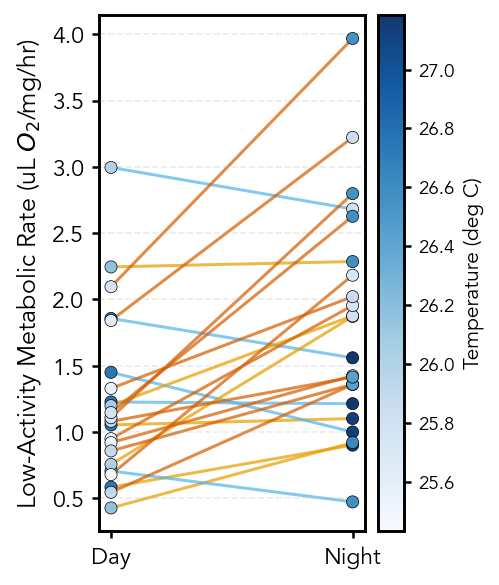

In [6]:
# Temperature slopegraph: Day (left) vs Night (right), with points colored by temp_C.
# Line hue follows the Figure 1 direction scheme; endpoint color carries temperature.

if paired_temp_df.empty:
    print('No paired temperature data available to plot.')
else:
    temp_plot_df = paired_temp_df.sort_values(['trial2', 'sample', 'environment']).copy()
    x_lookup = {'day': 0, 'night': 1}
    started_in_day_trial2 = {4, 5}

    fig_temp_slope, ax_temp_slope = plt.subplots(figsize=(3.35, max(4, 0.1 * paired_temp_df['couple'].nunique())))

    for _, group_df in temp_plot_df.groupby('couple', sort=False):
        if set(group_df['environment'].astype(str)) != {'day', 'night'}:
            continue

        day_row = group_df[group_df['environment'].astype(str) == 'day'].iloc[0]
        night_row = group_df[group_df['environment'].astype(str) == 'night'].iloc[0]
        y_day = float(day_row['RMR'])
        y_night = float(night_row['RMR'])
        trial2 = int(day_row['trial2'])

        if y_night > y_day:
            line_color = LIGHT_ORANGE if trial2 in started_in_day_trial2 else DARK_ORANGE
        else:
            line_color = LIGHT_BLUE if trial2 in started_in_day_trial2 else DARK_BLUE

        ax_temp_slope.plot(
            [x_lookup['day'], x_lookup['night']],
            [y_day, y_night],
            color=line_color,
            linewidth=1.45,
            alpha=0.72,
            zorder=1,
        )

    scatter = ax_temp_slope.scatter(
        temp_plot_df['environment'].astype(str).map(x_lookup),
        temp_plot_df['RMR'],
        c=temp_plot_df['temp_C'],
        cmap='Blues',
        s=34,
        edgecolors='black',
        linewidth=0.35,
        alpha=0.96,
        zorder=2,
    )

    ax_temp_slope.set_xticks([0, 1])
    ax_temp_slope.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax_temp_slope.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax_temp_slope.grid(axis='y', linestyle='--', alpha=0.25)

    cbar = fig_temp_slope.colorbar(scatter, ax=ax_temp_slope, pad=0.04)
    cbar.set_label('Temperature (deg C)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()


In [7]:
# Statistics for the paired small-vessel temperature check.
# Mixed model mirrors: RMR ~ environment + temp_C + (1 | couple), compared with RMR ~ environment + (1 | couple).

from scipy import stats
import statsmodels.formula.api as smf

if paired_temp_df.empty:
    print('No paired temperature data available for statistical testing.')
else:
    model_df = paired_temp_df.copy()

    full_model = smf.mixedlm(
        'RMR ~ C(environment) + temp_C',
        model_df,
        groups=model_df['couple'],
    ).fit(reml=False, method='lbfgs')
    base_model = smf.mixedlm(
        'RMR ~ C(environment)',
        model_df,
        groups=model_df['couple'],
    ).fit(reml=False, method='lbfgs')

    lr_stat = 2 * (full_model.llf - base_model.llf)
    lr_df = int(full_model.df_modelwc - base_model.df_modelwc)
    lr_p = stats.chi2.sf(lr_stat, lr_df)
    full_ci = full_model.conf_int()

    fixed_effect_rows = []
    for term in full_model.fe_params.index:
        fixed_effect_rows.append({
            'term': term,
            'estimate': float(full_model.fe_params[term]),
            'std_error': float(full_model.bse_fe[term]),
            'z_value': float(full_model.tvalues[term]),
            'p_value': float(full_model.pvalues[term]),
            'ci95_lower': float(full_ci.loc[term, 0]),
            'ci95_upper': float(full_ci.loc[term, 1]),
        })
    paired_temp_fixed_effects = pd.DataFrame(fixed_effect_rows)

    paired_temp_model_comparison = pd.DataFrame({
        'comparison': ['full: environment + temp_C vs base: environment'],
        'n': [int(len(model_df))],
        'groups': [int(model_df['couple'].nunique())],
        'logLik_full': [float(full_model.llf)],
        'logLik_base': [float(base_model.llf)],
        'lr_stat': [float(lr_stat)],
        'df': [lr_df],
        'p_value': [float(lr_p)],
        'pearson_r_temp_RMR': [float(model_df['temp_C'].corr(model_df['RMR']))],
    })

    print('Paired small-vessel mixed model: RMR ~ environment + temp_C + (1 | couple)')
    print('=' * 84)
    display(paired_temp_fixed_effects)

    print()
    print('Likelihood-ratio comparison for adding temp_C')
    print('=' * 84)
    display(paired_temp_model_comparison)

    # Sensitivity check using only rows retained in the main filtered analysis.
    filtered_model_df = model_df[model_df['filtered'] == True].copy()
    if filtered_model_df['couple'].nunique() >= 2 and len(filtered_model_df) > 4:
        filtered_full = smf.mixedlm(
            'RMR ~ C(environment) + temp_C',
            filtered_model_df,
            groups=filtered_model_df['couple'],
        ).fit(reml=False, method='lbfgs')
        filtered_base = smf.mixedlm(
            'RMR ~ C(environment)',
            filtered_model_df,
            groups=filtered_model_df['couple'],
        ).fit(reml=False, method='lbfgs')
        filtered_lr = 2 * (filtered_full.llf - filtered_base.llf)
        filtered_df = int(filtered_full.df_modelwc - filtered_base.df_modelwc)
        filtered_p = stats.chi2.sf(filtered_lr, filtered_df)
    else:
        filtered_lr = np.nan
        filtered_df = np.nan
        filtered_p = np.nan

    paired_temp_sensitivity = pd.DataFrame({
        'subset': ['R-style paired rows', 'filtered rows only'],
        'n': [int(len(model_df)), int(len(filtered_model_df))],
        'groups': [int(model_df['couple'].nunique()), int(filtered_model_df['couple'].nunique())],
        'temp_coef': [float(full_model.fe_params['temp_C']), float(filtered_full.fe_params['temp_C']) if not np.isnan(filtered_p) else np.nan],
        'temp_p_value': [float(full_model.pvalues['temp_C']), float(filtered_full.pvalues['temp_C']) if not np.isnan(filtered_p) else np.nan],
        'lr_p_value_add_temp_C': [float(lr_p), float(filtered_p) if not np.isnan(filtered_p) else np.nan],
    })

    print()
    print('Filtered-data sensitivity check')
    print('=' * 84)
    display(paired_temp_sensitivity)

    print()
    print('Caption-ready sentence:')
    print(
        f"In paired small-vessel measurements, adding temperature to an environment-only random-intercept model "
        f"did not improve model fit (likelihood-ratio chi-square={lr_stat:.3f}, df={lr_df}, p={lr_p:.3f}; "
        f"temp_C estimate={full_model.fe_params['temp_C']:.3f}, p={full_model.pvalues['temp_C']:.3f}; "
        f"n={len(model_df)}, couples={model_df['couple'].nunique()}). "
        f"The same conclusion held when restricted to filtered rows only (p={filtered_p:.3f})."
    )


Paired small-vessel mixed model: RMR ~ environment + temp_C + (1 | couple)


,term,estimate,std_error,z_value,p_value,ci95_lower,ci95_upper
0,Intercept,5.782707,6.961020,0.830727,0.406128,-7.860643,19.426056
1,C(environment)[T.night],0.662604,0.177685,3.729097,0.000192,0.314348,1.010859
2,temp_C,-0.174934,0.267405,-0.654192,0.512988,-0.699037,0.349169



Likelihood-ratio comparison for adding temp_C


,comparison,n,groups,logLik_full,logLik_base,lr_stat,df,p_value,pearson_r_temp_RMR
0,full: environment + temp_C vs base: environment,44,22,-44.17191,-44.378423,0.413025,1,0.520438,-0.064543



Filtered-data sensitivity check


,subset,n,groups,temp_coef,temp_p_value,lr_p_value_add_temp_C
0,R-style paired rows,44,22,-0.174934,0.512988,0.520438
1,filtered rows only,34,17,0.407666,0.294483,0.307534



Caption-ready sentence:
In paired small-vessel measurements, adding temperature to an environment-only random-intercept model did not improve model fit (likelihood-ratio chi-square=0.413, df=1, p=0.520; temp_C estimate=-0.175, p=0.513; n=44, couples=22). The same conclusion held when restricted to filtered rows only (p=0.308).


In [8]:
# Save supplemental temperature slopegraph to files.
figures_dir = Path.cwd() / "../figures/supplemental"
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig_temp_slope' in locals():
    temp_pdf_path = (figures_dir / 'FigureS3_PairedTemperatureSlopeGraph.pdf').resolve()

    fig_temp_slope.savefig(temp_pdf_path, bbox_inches='tight')

    print(f"Saved temperature slopegraph PDF: {temp_pdf_path}")
else:
    print('No supplemental temperature slopegraph found. Run the temperature plotting cell first.')


Saved temperature slopegraph PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/supplemental/FigureS3_PairedTemperatureSlopeGraph.pdf
